In [187]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input,Lambda,UpSampling2D,Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,BatchNormalization, Activation,ConvLSTM2D,TimeDistributed, GlobalAveragePooling2D, GlobalMaxPooling2D, Add, multiply,Reshape
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
from tensorflow.keras.callbacks         import LearningRateScheduler,Callback

from sklearn.metrics                    import mean_squared_error,r2_score,mean_absolute_error

import sys
import os
import numpy as np
import math
import time
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

In [188]:
#directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_Masked'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

nbatch = 10

In [189]:
def dataset_array(g_path,p_path,v_path,vx_path,vy_path):
    """
    Loads and preprocesses a single set of data files.
    This function is designed to be used with tf.data.Dataset.map().
    """
    def load_array(geo,p,v,vx,vy):
        '''
        Inner function executed by tf.numpy_function.
        It loads numpy arrays from the provided file paths
        '''
        pre = np.load(p)   
        vel = np.load(v)
        velx = np.load(vx)
        vely = np.load(vy)
        g = np.load(geo)
        y = np.concatenate([pre, vel, velx, vely], axis=-1)
        return g,y
    
    x,y= tf.numpy_function(load_array,[g_path,p_path,v_path, vx_path,vy_path], [tf.float64,tf.float64])

    y.set_shape([y.shape[0],y.shape[1],y.shape[2]])
    x.set_shape([x.shape[0],x.shape[1],x.shape[2]])
  
    return x,y 


def create_dataset(p_path,v_path, vx_path,vy_path,g_path,batch_size = nbatch):
    p_files = sorted(glob.glob(os.path.join(p_path, "*.npy")))
    v_files = sorted(glob.glob(os.path.join(v_path, "*.npy")))
    vx_files = sorted(glob.glob(os.path.join(vx_path, "*.npy")))
    vy_files = sorted(glob.glob(os.path.join(vy_path, "*.npy")))
    g_files = sorted(glob.glob(os.path.join(g_path, "*.npy")))

    dataset = tf.data.Dataset.from_tensor_slices((p_files,v_files,vx_files,vy_files,g_files))
    dataset = dataset.map(dataset_array, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    return dataset

train_ds =create_dataset(gtrain,ptrain,vtrain,vxtrain,vytrain)
test_ds  =create_dataset(gtest,ptest,vtest,vxtest,vytest)
valid_ds =create_dataset(gval,pval,vval,vxval,vyval)

In [190]:
num_epochs    =50
patience      =10     # How long to wait after last time validation loss improved
LR            =0.001

# Model name
model_names=['ConvLSTM']
NamesKeras=['Arch_1.keras','Arch_2.keras','Arch_3.keras','Arch_4.keras','Arch_5.keras']
model_name    =model_names[0]
#save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1

number_of_filters = [8,16,32,64,128,256,512]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
DECAY_RATE=0.04

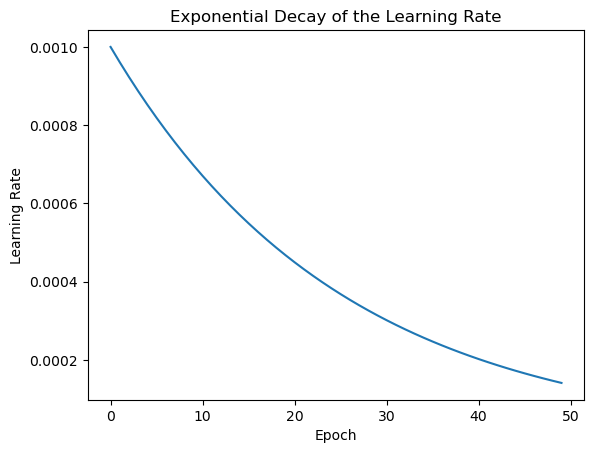

In [191]:
def exponential_decay(epoch,lr_ini=LR,decay_rate=DECAY_RATE,epochs=num_epochs):
    if epoch < epochs*0.001:
        return lr_ini
    else:
        return  lr_ini * np.exp(-decay_rate*epoch)
    
epochs = np.arange(num_epochs)
learning_rates = [exponential_decay(epoch) for epoch in epochs]


plt.plot(epochs, learning_rates, label="Learning Rate")
plt.title("Exponential Decay of the Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(False)
plt.show()  

In [192]:
lr_scheduler = LearningRateScheduler(lambda epoch: exponential_decay(epoch), verbose=1)
optimizer = Adam(learning_rate=LR)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',  min_delta=1e-2, patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Test1_Results_weights/Test1_Best_weights.weights.h5'
checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)

In [193]:

class R2RMSECallback(Callback):
    def __init__(self, data_val):
        self.data_val=data_val
        self.rmse = []
        self.r2=[]

    def on_epoch_end(self, epoch, logs=None):
        ytrue =[]
        ypred=[]
        for x_batch, y_batch in self.data_val:
            y_pred_batch = self.model.predict(x_batch,verbose=0)
            ytrue.append(y_batch)
            ypred.append(y_pred_batch)
        y_true_all = np.concatenate(ytrue, axis=0)
        y_pred_all = np.concatenate(ypred, axis=0)

        rmse = np.sqrt(mean_squared_error(y_true_all.flatten(), y_pred_all.flatten()))
        r2 = r2_score(y_true_all.flatten(), y_pred_all.flatten())

        self.rmse.append(rmse)
        self.r2.append(r2)

        print(f"==> Epoch {epoch+1}: RMSE = {rmse:.4f}, R² = {r2:.4f}")


In [194]:
def make_model():
    
    image_input = Input((img_height, img_width, channel))
    
    reshaped_input = layers.Reshape((1,img_height, img_width, channel))(image_input)
    """
    input_shape: (time_steps, height, width, channels)
    """

    x = layers.ConvLSTM2D(filters=16, kernel_size=3, padding="same", return_sequences=True)(reshaped_input)
    x = layers.BatchNormalization()(x)
    x = layers.ConvLSTM2D(filters=32, kernel_size=3, padding="same", return_sequences=True)(x)
    x = layers.BatchNormalization()(x) 
    x = layers.ConvLSTM2D(filters=64, kernel_size=3, padding="same", return_sequences=False)(x)
    x = layers.BatchNormalization()(x)
    print(x.shape)
    flows_out = Conv2D(4, (1, 1), activation=f_activation_last,name='flows_output',padding="same")(x)

    # construct model
    model =  keras.Model(inputs=image_input, outputs=[flows_out],name= model_name)
    
    model.summary()

    model.compile(optimizer=optimizer, 
              loss = 'mean_squared_error',
              
              metrics= ['mae'] )

    return model  

In [195]:
M=make_model()

(None, 64, 256, 64)


Model: "ConvLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 64, 256, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 1, 64, 256, 16) │         9,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 64, 256, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 1, 64, 256, 32) │        55,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 64, 256, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 64, 256, 64)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 256, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flows_output (Conv2D)           │ (None, 64, 256, 4)     │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 287,428 (1.10 MB)

 Trainable params: 287,204 (1.10 MB)

 Non-trainable params: 224 (896.00 B)

In [196]:
print("Starting trainig")

rrmse = R2RMSECallback(valid_ds)
start_time_for_fit = time.time()
history = M.fit(train_ds,epochs=num_epochs,validation_data = valid_ds,callbacks=[lr_scheduler,tf.keras.callbacks.ModelCheckpoint("Unet.keras",save_best_only=True),early_stopping,checkpoint_cb,rrmse ])
end_time_for_fit = time.time()
Training_time = end_time_for_fit - start_time_for_fit
print(f"TRAINING TIME IN  {Training_time:.4f} segundos.")
M.save(NamesKeras[0])

Starting trainig

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0523 - mae: 0.1184WARNING:tensorflow:6 out of the last 369 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7faf97a12a60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


==> Epoch 1: RMSE = 0.2551, R² = -2.3908
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 191ms/step - loss: 0.0521 - mae: 0.1182 - val_loss: 0.0651 - val_mae: 0.2142 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0009607894391523232.
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0132 - mae: 0.0729==> Epoch 2: RMSE = 0.2551, R² = -2.3908
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 172ms/step - loss: 0.0132 - mae: 0.0729 - val_loss: 0.0651 - val_mae: 0.2142 - learning_rate: 9.6079e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009231163463866358.
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0128 - mae: 0.0712==> Epoch 3: RMSE = 0.2551, R² = -2.3908
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 173ms/step - loss: 0.0128 - mae: 0.0712 - val_loss: 0.0651 - val_mae: 0.2142 - learning_rate: 9.2312e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0008869204367171575.
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0

2025-06-13 17:26:08.494941: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


==> Epoch 15: RMSE = 0.1117, R² = 0.3503
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 172ms/step - loss: 0.0123 - mae: 0.0699 - val_loss: 0.0125 - val_mae: 0.0737 - learning_rate: 5.7121e-04

Epoch 16: LearningRateScheduler setting learning rate to 0.0005488116360940264.
Epoch 16/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0122 - mae: 0.0698==> Epoch 16: RMSE = 0.1105, R² = 0.3635
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 173ms/step - loss: 0.0122 - mae: 0.0698 - val_loss: 0.0122 - val_mae: 0.0710 - learning_rate: 5.4881e-04
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6.
TRAINING TIME IN  397.7114 segundos.


In [197]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0138 - mae: 0.0799
Evaluation results:
loss: 0.0134
compile_metrics: 0.0792


In [198]:
xtrue=[]
ytrue=[]
for x,y in test_ds:
    xtrue.append(x.numpy())
    ytrue.append(y.numpy())
ypred = list()  
start_time_pred=time.time()  
for i in range(len(ytrue)):    
    ypred.append(M.predict(xtrue[i]))
end_time_pred=time.time()  
inference_time = end_time_pred - start_time_pred
print(f"PREDICTING TIME IN  {inference_time:.4f} seconds.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━

In [199]:
def plotting():
    n = random.randint(0, len(xtrue)-1)
    m = random.randint(0, nbatch-1)
    titles = [ 'P pred', 'P true','V pred', 'V true','Vx pred', 'Vx true','Vy pred', 'Vy true']
    fig, axes = plt.subplots(4, 3, figsize=(16, 10))
    
    error=[]
    for i in range(4):
            error.append(np.abs(ytrue[m][n][:,:,i]- ypred[m][n][:,:,i]))

            axes[i,0].imshow(ypred[m][n][:,:,i], cmap='gray')
            axes[i, 0].set_title(titles[2*i])
            axes[i, 0].axis('off')

            axes[i,1].imshow(ytrue[m][n][:,:,i], cmap='gray')
            axes[i, 1].set_title(titles[2*i+1])
            axes[i, 1].axis('off')

            e=axes[i,2].imshow(error[0], cmap='turbo')
            axes[i, 2].set_title('Absolute Error')
            axes[i, 2].axis('off')
            plt.colorbar(e, ax=axes[i,2], fraction=0.046)

    for ax in axes.flat:
        ax.axis('off')

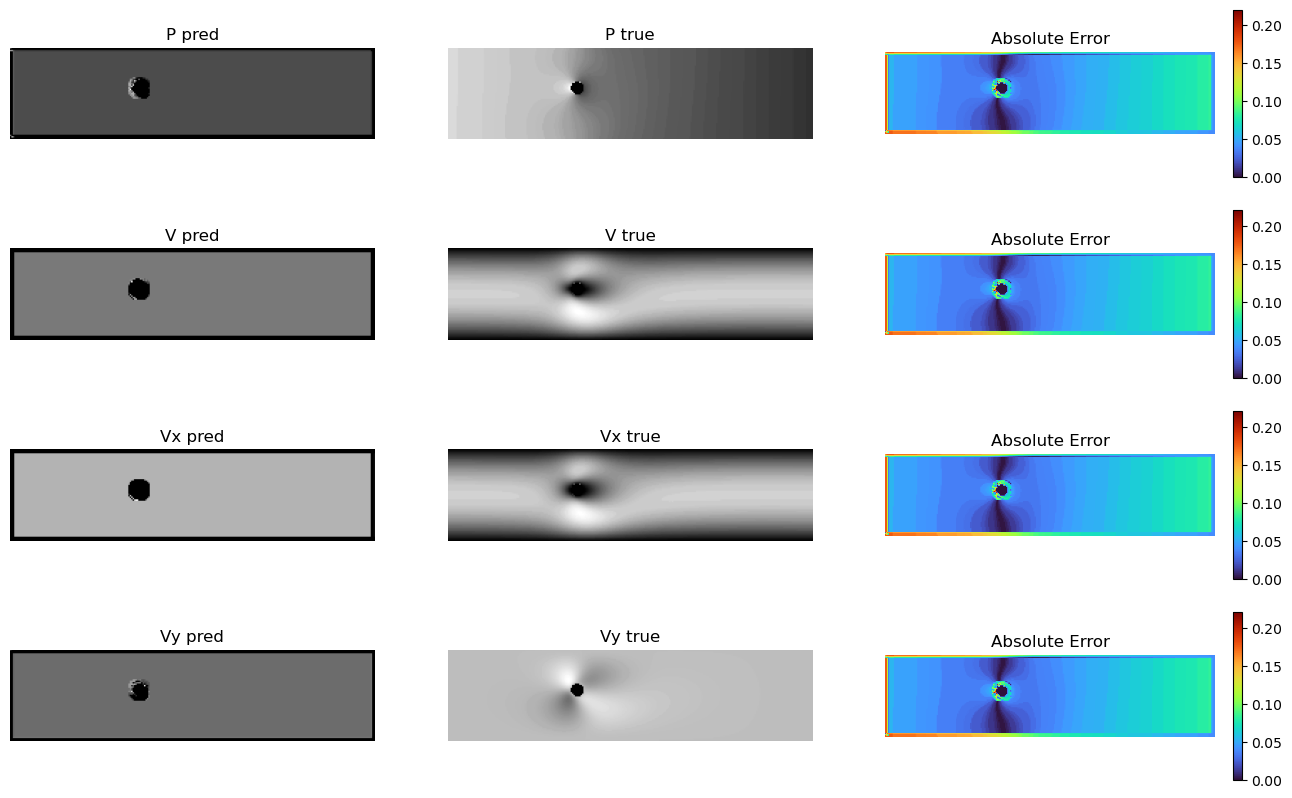

In [200]:
plotting()

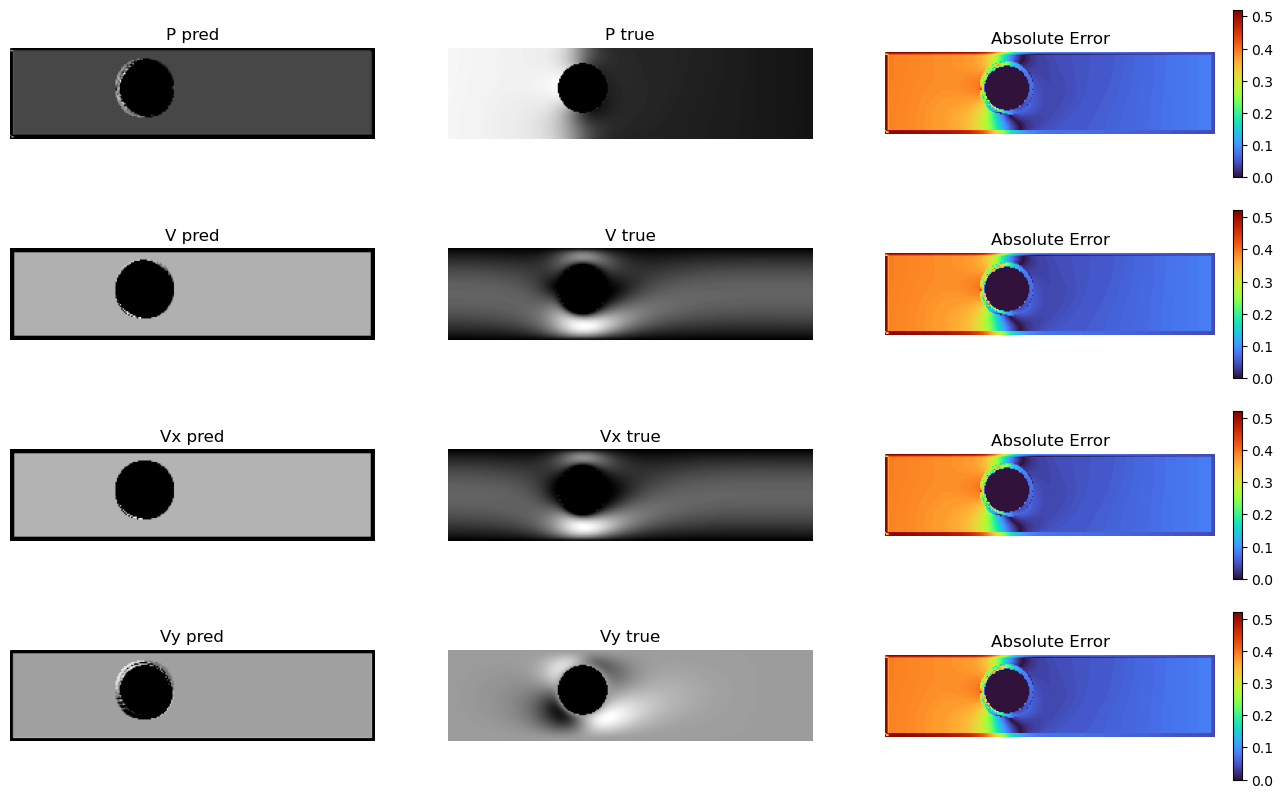

In [203]:
plotting()

In [208]:

plt.plot(rrmse.rmse['val_loss'], label='RMSE')
plt.xlabel('Époch')
plt.ylabel('RMSE')
plt.title(' RMSE per Epoch')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(rrmse.r2, label='RMSE')
plt.xlabel('Époch')
plt.ylabel('R²')
plt.title(' R² per Epoch')
plt.legend()
plt.grid(True)
plt.show()


class RMSE_R2_TrainVal_Callback(Callback):
    def __init__(self, data_train, data_val):
        self.data_train = data_train
        self.data_val = data_val
        self.rmse_train, self.rmse_val = [], []
        self.r2_train, self.r2_val = [], []

    def compute_metrics(self, data):
        y_true_all, y_pred_all = [], []
        for x_batch, y_batch in data:
            y_pred_batch = self.model.predict(x_batch, verbose=0)
            y_true_all.append(y_batch)
            y_pred_all.append(y_pred_batch)
        y_true_all = np.concatenate(y_true_all, axis=0)
        y_pred_all = np.concatenate(y_pred_all, axis=0)
        rmse = np.sqrt(mean_squared_error(y_true_all.flatten(), y_pred_all.flatten()))
        r2 = r2_score(y_true_all.flatten(), y_pred_all.flatten())
        return rmse, r2

    def on_epoch_end(self, epoch, logs=None):
        rmse_tr, r2_tr = self.compute_metrics(self.data_train)
        rmse_val, r2_val = self.compute_metrics(self.data_val)

        self.rmse_train.append(rmse_tr)
        self.rmse_val.append(rmse_val)
        self.r2_train.append(r2_tr)
        self.r2_val.append(r2_val)

        print(f"Epoch {epoch+1}: RMSE Train={rmse_tr:.4f}, RMSE Val={rmse_val:.4f}, R² Train={r2_tr:.4f}, R² Val={r2_val:.4f}")


TypeError: list indices must be integers or slices, not str

In [ ]:
lt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Extraemos el historial de pérdida (MSE) y calculamos la raíz para obtener RMSE
rmse_hist_simple = np.sqrt(historia_simple.history['val_loss'])
rmse_hist_complejo = np.sqrt(historia_complejo.history['val_loss'])
plt.plot(rmse_hist_simple, label='Modelo Simple - RMSE Validación', color='blue')
plt.plot(rmse_hist_complejo, label='Modelo Complejo - RMSE Validación', color='red')
plt.title('Curvas de Aprendizaje Comparativas')
plt.xlabel('Épocas')
plt.ylabel('RMSE de Validación')
plt.legend()
plt.grid(True)

In [ ]:
# Recolectar predicciones
y_preds = []
y_trues = []

for x_batch, y_batch in test_ds:
    y_pred = M.predict(x_batch)
    y_preds.append(y_pred)
    y_trues.append(y_batch)
    
y_preds = np.concatenate(y_preds, axis=0)  # (N, H, W, 4)
y_trues = np.concatenate(y_trues, axis=0)